In [2]:
import pandas as pd

In [6]:
df = pd.read_csv('amazon_alexa.tsv', sep='\t')

In [7]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [9]:
df['feedback'].value_counts()

,count
feedback,
1,2893
0,257


In [10]:
df['rating'].value_counts().sort_index()

,count
rating,
1,161
2,96
3,152
4,455
5,2286


In [11]:
def get_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

In [12]:
df[['rating', 'sentiment']].head(10)

,rating,sentiment
0,5,Positive
1,5,Positive
2,4,Positive
3,5,Positive
4,5,Positive
5,5,Positive
6,3,Neutral
7,5,Positive
8,5,Positive
9,5,Positive


In [13]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,2741
Negative,257
Neutral,152


In [14]:
df["sentiment"]

,sentiment
0,Positive
1,Positive
2,Positive
3,Positive
4,Positive
...,...
3145,Positive
3146,Positive
3147,Positive
3148,Positive


In [15]:
df[df['verified_reviews'].isnull()]

,rating,date,variation,verified_reviews,feedback,sentiment
473,2,29-Jun-18,White,NaN,0,Negative


In [16]:
df = df.dropna(subset=['verified_reviews'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3149 entries, 0 to 3149
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3149 non-null   int64 
 1   date              3149 non-null   object
 2   variation         3149 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3149 non-null   int64 
 5   sentiment         3149 non-null   object
dtypes: int64(2), object(4)
memory usage: 172.2+ KB


In [18]:
df['verified_reviews'].head(10)

,verified_reviews
0,Love my Echo!
1,Loved it!
2,"Sometimes while playing a game, you can answer..."
3,I have had a lot of fun with this thing. My 4 ...
4,Music
5,I received the echo as a gift. I needed anothe...
6,"Without having a cellphone, I cannot use many ..."
7,I think this is the 5th one I've purchased. I'...
8,looks great
9,Love it! I’ve listened to songs I haven’t hear...


In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_reviews'] = df['verified_reviews'].apply(clean_text)

In [20]:
df[['verified_reviews', 'cleaned_reviews']].head(10)

,verified_reviews,cleaned_reviews
0,Love my Echo!,love my echo
1,Loved it!,loved it
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr...
4,Music,music
5,I received the echo as a gift. I needed anothe...,i received the echo as a gift i needed another...
6,"Without having a cellphone, I cannot use many ...",without having a cellphone i cannot use many o...
7,I think this is the 5th one I've purchased. I'...,i think this is the th one ive purchased im wo...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love it ive listened to songs i havent heard s...


In [21]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [23]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_stopwords)

In [24]:
df[['verified_reviews', 'cleaned_reviews']].head(10)

,verified_reviews,cleaned_reviews
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaurs control ...
4,Music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone cannot use many features ipa...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love ive listened songs havent heard since chi...


In [25]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [26]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

df['cleaned_reviews'] = df['cleaned_reviews'].apply(lemmatize_text)

In [27]:
df[['verified_reviews', 'cleaned_reviews']].head(10)

,verified_reviews,cleaned_reviews
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...
4,Music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone cannot use many feature ipad...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...
8,looks great,look great
9,Love it! I’ve listened to songs I haven’t hear...,love ive listened song havent heard since chil...


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['cleaned_reviews'])

In [29]:
print(X.shape)

(3149, 3834)


In [30]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36463 stored elements and shape (3149, 3834)>
  Coords	Values
  (0, 1986)	0.655413022522997
  (0, 1031)	0.7552706600333879
  (1, 1987)	1.0
  (2, 3100)	0.25536042474149956
  (2, 2460)	0.2307488626654357
  (2, 1366)	0.26233904459218693
  (2, 177)	0.4819441085017608
  (2, 2620)	0.21987798764036956
  (2, 740)	0.3106932736885365
  (2, 115)	0.13535647643359464
  (2, 2873)	0.2136461009196526
  (2, 1426)	0.19507802061826537
  (2, 3798)	0.29320639598870246
  (2, 1919)	0.13874653441945378
  (2, 4)	0.20584971602923754
  (2, 3516)	0.21007398891777626
  (2, 1911)	0.19764092941293102
  (2, 284)	0.2654515193665143
  (2, 1572)	0.17973254516032655
  (3, 2460)	0.22301762243871806
  (3, 1366)	0.2535493753770866
  (3, 1919)	0.13409783203439962
  (3, 1911)	0.19101897043002333
  (3, 1980)	0.20448284071020503
  (3, 1345)	0.18522380751203074
  :	:
  (3147, 3038)	0.16017187665552904
  (3147, 627)	0.147805692870627
  (3147, 3294)	0.1538893720027753
 

In [31]:
from sklearn.model_selection import train_test_split

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2519, 3834)
Testing data: (630, 3834)


In [33]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [34]:
y_pred = model.predict(X_test)

In [35]:
print(y_pred[:20])

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive']


In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8698412698412699


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        51
     Neutral       0.00      0.00      0.00        31
    Positive       0.87      1.00      0.93       548

    accuracy                           0.87       630
   macro avg       0.29      0.33      0.31       630
weighted avg       0.76      0.87      0.81       630



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    Negative       0.71      0.49      0.58        51
     Neutral       0.44      0.52      0.48        31
    Positive       0.95      0.97      0.96       548

    accuracy                           0.91       630
   macro avg       0.70      0.66      0.67       630
weighted avg       0.90      0.91      0.90       630



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

[[ 25   9  17]
 [  3  16  12]
 [  7  11 530]]


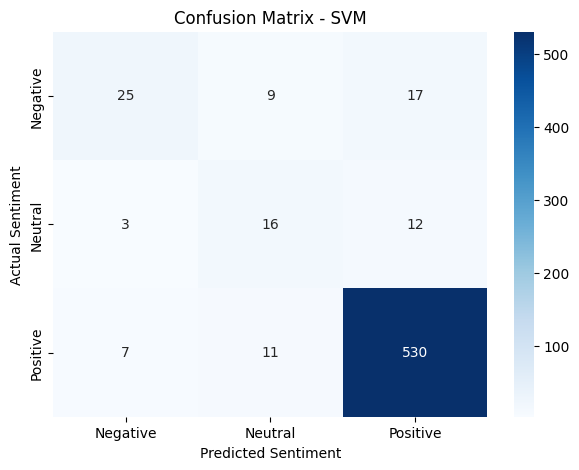

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix - SVM')
plt.show()

In [42]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    cleaned = remove_stopwords(cleaned)
    cleaned = lemmatize_text(cleaned)

    vector = tfidf.transform([cleaned])
    prediction = svm_model.predict(vector)

    return prediction[0]

In [43]:
reviews = [
    "I absolutely love this product!",
    "This product is terrible and useless.",
    "It is okay, nothing special."
]

for review in reviews:
    print(review, "→", predict_sentiment(review))

I absolutely love this product! → Positive
This product is terrible and useless. → Negative
It is okay, nothing special. → Positive
